# Problem Set 2, Exercise 3
Pryce Davies and Richard Chen.  

 Assuming that $\epsilon_t\stackrel{i.i.d}{\sim}N(0,1)$, use the data in ps2\_ex3.csv to estimate the parameters $(\beta,\phi,\delta)$ using MLE.  
 \
 Likelihood Function (for $j=2$):
$$
\mathcal{L}(n_t)
= \prod_{t=1}^T \Bigg(
\mathbf{1}\{n_t = 0\}\, \mathbb{P}(\epsilon_t < \phi - x_t \beta)

+ \mathbf{1}\{n_t = 1\}\,
\mathbb{P}\!\left(\phi - x_t \beta \le \epsilon_t < \phi + \delta \ln(2) - x_t \beta\right)
\\
+ \mathbf{1}\{n_t = 2\}\,
\mathbb{P}\!\left(\epsilon_t \ge \phi + \delta \ln(2) - x_t \beta\right)
\Bigg)
$$

In [182]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
from scipy.optimize import minimize

In [183]:
# Read in Data
df = pd.read_csv('data/ps2_ex3.csv')
max(df['n'])

24

In [184]:
# Estimate probability given \beta, \phi, \delta
def cond_prob_theta(data,theta):
    eps = 1e-8
    beta = theta[0]
    phi = theta[1]
    delta = theta[2]
    # initialize list of probs
    prob = pd.DataFrame(np.zeros((len(data['x']),int(max(data['n']))+1)))
    # compute bounds and probabiliites for each choice
    for i in range(int(max(data['n']))+1):
        if i == 0:
            prob.iloc[:,i]  = norm.cdf(phi- beta * data['x'])    
        elif i == max(data['n']):
            prob.iloc[:,i]  = 1-norm.cdf(phi- beta * data['x']+ delta * np.log(24))    
        else:
            prob.iloc[:,i]  = norm.cdf(phi- beta * data['x']+ delta *np.log(i+1)) - norm.cdf(phi- beta * data['x']+delta *np.log(i)) 
    
    prob = prob.clip(lower=eps, upper=1 - eps)
    return prob


In [185]:
# Likelihood function (adapted from notebook)
def likelihood(data, prob):
    """The likelihood function with the given choice probability
    
        Parameters
        ----------
        data : `DataFrame`
            The data that contains the actions and states.
        dgp : `dgp`
            The primitives of the DDC model.
        prob : `ndarray`
            A matrix of choice probabilities.
    """
    
    l = 0.
    for i in range(len(data['x'])):
        num_enter = data['n'].iloc[i]     
        # Append the right probability depending on the choice and state
        l += np.log(prob.iloc[i, num_enter]) 
            
    return -l/(len(data['x'])*max(data['n']))

In [186]:
# MLE Estimation

def entry_mle(data, n_starts=20, seed=563):
    """
     MLE w simple multi-start global search
    """
    rng = np.random.default_rng(seed)

    def ll(x):
        prob = cond_prob_theta(data, x)
        return likelihood(data, prob)  

    best_res = None
    best_val = np.inf

    for _ in range(n_starts):
        x0 = np.array([1, 1, 1]) + rng.normal(scale=1.0, size=3)
        res = minimize(ll, x0)

        if res.fun < best_val:
            best_val = res.fun
            best_res = res

    return best_res

In [187]:
out = entry_mle(df)
out.x

array([ 2.14775052,  1.65127421, 10.5090626 ])

In [188]:
table = cond_prob_theta(df,out.x)
df['MLE_implied_num'] = table.idxmax(axis=1)
np.mean(df['MLE_implied_num'] == df['n'])

np.float64(0.75)

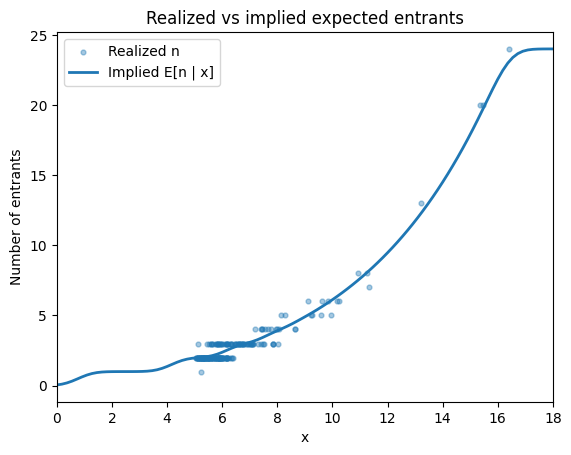

In [191]:

def plot_implied_n_vs_x(data, theta):
    # ----- create uniform grid of x -----
    x_grid = np.linspace(0, 18, 100)
    grid_df = pd.DataFrame({"x": x_grid, "n": np.full_like(x_grid,24)})  

    # ----- implied probabilities on grid -----
    prob = cond_prob_theta(grid_df, theta)

    # implied expected value E[n | x]
    n_vals = np.arange(prob.shape[1])
    n_exp = prob.to_numpy() @ n_vals

    # ----- realized data (still from actual sample) -----
    x_true = np.asarray(data["x"])
    n_true = np.asarray(data["n"])

    order_true = np.argsort(x_true)

    # ----- plot -----
    plt.figure()

    # realized scatter
    plt.scatter(x_true[order_true], n_true[order_true],
                s=12, alpha=0.4, label="Realized n")

    # implied smooth curve
    plt.plot(x_grid, n_exp, linewidth=2, label="Implied E[n | x]")

    plt.xlabel("x")
    plt.ylabel("Number of entrants")
    plt.title("Realized vs implied expected entrants")

    plt.xlim(0, 18)
    plt.legend()
    plt.show()

plot_implied_n_vs_x(df, out.x)